# Exercise 1 for the class EE-568 Theory and Methods of Reinforcement Learning taught at EPFL in Spring 2026 by Prof. Volkan Cevher

### Names and Sciper numbers

#### Group Member 1:
Name: Kevin Abou Jaoude

Sciper number: 358300

#### Group Member 2:
Name: Fuad Khuri

Sciper number: 357574

#### Group Member 3:
Name: Youssef Dib

Sciper number: 339964

### LLM Usage

You are encouraged **not to use** LLMs or other AI tools so that you can fully engage with and learn the course material. Uploading the full document or copy-pasting the questions into an AI tool are strictly not allowed. 

If you do use them at any point, please clearly and transparently disclose what tool was used, and how in the next cell. 

If AI use is suspected but not clearly explained, we reserve the right to ask follow-up questions to clarify your understanding of the work. 

In [ ]:
import os
from typing import List

import numpy as np

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import sys

sys.path.insert(0, "src/")
from environment import GridWorldEnvironment
from MDPsolver import MDPsolver
from plot import plot_log_lines, plot_lines
%load_ext autoreload
%autoreload 2

# Dynamic Programming exercise

We will make use of the operators introduced in the slides of lectures 1 and 2. 
$(T V)(s)$, $\mathcal{G}$ and $T^{\pi}$

Before diving into the implementation of Value Iteration or Policy Iteration, we instantiate an environment using the library in the foilder `src`.

The gridworld environment is instantiated via the class `GridWorldEnvironment`. It takes 4 input values:

- `reward_mode` : integer between 0 and 3 for different reward profiles
- `size`: Gridworld size
- `prop`: probability assigned to the event that the agent do not follow the chosen action but another one selected uniformely at random.
- `gamma`: the discount factor of the environment.

In [ ]:
reward_mode = 2 # put an image to show which is the reward
size = 10 
prop = 0
gamma=0.99 # rename discount_factor
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)

Below, we illustrate how to access the gridworld environment, i.e. how to access the reward, the transition matrix and the discount factor.

In [ ]:
size = 3
gridworld_example = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)


***Interface with a Gridworld instance***
- `print(gridworld.n_states)` #return the number of states
- `print(gridworld.n_actions)` #return the number of actions
- `print(gridworld.r)` #return a matrix where each element indicates the reward corresponding to each (state, action) pair.
- `print(gridworld.gamma)` # return the discount factor
- `print(gridworld.sparseT[action])` #Input: action, Return: a matrix containing the state-to-state transition probabilities for the action passed as input.



<img src="src/vis_gridworld.png" alt="fishy" class="bg-primary" width="400px">

Then we set up the solver object that will implement the routine needed to evaluate the value of the produced policies

In [ ]:
solver = MDPsolver(gridworld)

We will use this solver to compute the optimal value function to measure the suboptimality of the policies produced by value iteration or policy iteration.

To access the optimal value function use `solver.v`.

In [ ]:
solver.value_iteration()

## Ex 1: Value Iteration [20 pts.]

### 1.1 Implement value iteration

In [ ]:
def value_iteration(env, tol=1e-10):
    """Inplementation of value iteration, note that the implementation is based on value iteration mentioned in the lecture.
    Args:
        env: environment
        tol: a scalar to dermerminate whether the algorithm convergences
    Returns:
        policies: policy  at each iteration (list)
        vs: value functions at each iteration (list)
    """
    policies = []
    vs = []
    v = np.zeros(env.n_states) # initialize value function
    q = np.zeros((env.n_states, env.n_actions)) #initialize Q-value
    
    while True:
        v_old = np.copy(v) # save a copy of value function for the convergence criterion at the step
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v) # calculate Q-value
        v = np.max(q, axis=1) # update value function
        policies.append(np.argmax(q, axis=1)) # obtain policy
        vs.append(v)
        if np.linalg.norm(v - v_old) < tol: # convergence criterion
            break
    return policies, vs

In [ ]:
policies, vs = value_iteration(gridworld)

### 1.2: Evaluate the extracted policies

For the evaluation of the sequence of policies, i.e. computing $V^\pi$ for each policy $\pi$ we recall that $V^\pi$ is the fixed point $V^\pi = T^\pi (V^\pi)$.
In the following code, we ask you to apply the operator $T^\pi$ a number of time sufficient to find a value $V$ such that $ || T^\pi(V) - V || \leq \mathrm{tol}$

In [ ]:
def evaluate_policy_sequence(policies, env, tol=1e-10):
    """Inplementation of policy evaluation through iteratively applying policy value iteration 
    Args:
        policies: a list of policies obtained by section 1.1
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
    Returns:
        values: a list of value function for each policy
    """
    values = []
    for pi in policies:
        v = np.zeros(env.n_states) # initialize value function
        q = np.zeros((env.n_states, env.n_actions)) #initialize Q-value
        while True:
            v_old = np.copy(v) # save a copy of value function for the convergence criterion at the step
            for a in range(env.n_actions):
                q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v) #calculate Q-value
            for s in range(env.n_states):
                action_taken = pi[s] # obtain the action determined by the policy
                v[s] = q[s, action_taken] #calculate value function by $v(s) = Q(s,pi(s))$
            if np.linalg.norm(v - v_old) < tol: # convergence criterion
                break
        values.append(v)
    return values


In [ ]:
values = evaluate_policy_sequence(policies, gridworld)

### 1.3: Plot the results 

Plot using the method ```plot_lines(list_to_plot, list_name, axis_label, folder, title, x_axis = None, show = False) ```

Compute both the iterates $V_t$ produced by value iteration and the value function achieved by the extracted policies $V^{\pi_t}$ with $\pi_t = \mathcal{G}(V_t)$. What do you observe ?


???

In [ ]:
def compute_subopt(values, v_star):
    """
    Args:
        values: a list of value function.
        v_star: the optimal value function obtained by MDP.solver
    Returns:
        subopts: an array indicates the suboptimality.
    """
    subopts = []
    for v in values:
        i = np.argmax(np.abs(v - v_star))
        subopts.append(-v[i] + v_star[i])
    return np.array(subopts)

In [ ]:
plot_lines([compute_subopt(vs, solver.v)], [r"Subopt of $V^t$"], ["Iteration", "Subopt"], "figs", "VI.pdf", show = True)

**Question** : 
- Prove that $T$ is a contraction, that is $|| T(V) - T(V') ||_{\infty} \leq \gamma || V - V' ||_{\infty}$.
- Why the iterates of Value Iterations are an upper bound to $V^\star$ ? How is this possible considering that $V^\star \triangleq \max_{\pi \in \Pi} V^{\pi}$ ?

**Answers**

1. Prove that T is a contraction

We want to show that $| T(V) - T(V') |{\infty} \leq \gamma | V - V' |{\infty}$.

For any state $s$:

$$T(V) - T(V') = \max_a \left[ r(s,a) + \gamma \sum_{s'} P(s'|s,a) V(s') \right] - \max_a \left[ r(s,a) + \gamma \sum_{s'} P(s'|s,a) V'(s') \right]$$

Let $a^*$ be the action achieving the max for $V$. Then:

$$T(V) - T(V') \leq r(s,a) + \gamma \sum_{s'} P(s'|s,a) V(s') - r(s,a) - \gamma \sum_{s'} P(s'|s,a) V'(s')$$

$$= \gamma \sum_{s'} P(s'|s,a^*) [V(s') - V'(s')]$$

$$\leq \gamma | V - V' |_{\infty}$$

where the last step uses the fact that the transition probabilities sum to 1. By symmetry (swapping $V$ and $V'$), we also get $T(V') - T(V) \leq \gamma | V - V' |{\infty}$. Thus $|T(V) - T(V')| \leq \gamma | V - V' |{\infty}$ for all $s$, which gives us the result.

2. Why are the VI iterates an upper bound to $V^\star$?

This seems counterintuitive at first since $V^\star = \max_{\pi} V^{\pi}$ is already the best you can do under any policy. However, the iterates $V_t$ produced by value iteration starting from $V_0 = 0$ are not themselves value functions of any specific policy but they are just vectors in $\mathbb{R}^{|S|}$.

In our case, we initialize $V_0 = 0$ and the rewards are all negative (as we can see from the plot where suboptimality is negative). Since $T$ is monotone and $V^\star = T(V^\star)$, starting from $V_0 = 0 \geq V^\star$ (because $V^\star$ has negative entries), we get by induction $V_1 = T(V_0) \geq T(V^\star) = V^\star$, and more generally $V_t \geq V^\star$ for all $t$.

So the iterates approach $V^\star$ from above because our initialization $V_0 = 0$ happens to be componentwise larger than $V^\star$. The key insight is that $V_t$ is not the value function of any real policy -- it is just an intermediate computation that converges to $V^\star$. No policy actually achieves $V_t$, so there is no contradiction with $V^\star$ being the maximum over all policies.

In [ ]:
plot_lines([compute_subopt(values, solver.v)], ["Subopt of $V^{\pi_t}$"], ["Iteration", "Subopt"], "figs", "VI.pdf", show = True)

To better appreciate the difference in the convergence plot use log scale.

In [ ]:
plot_log_lines([-compute_subopt(vs, solver.v), compute_subopt(values, solver.v)], 
               [r"Subopt of $V^t$", "Subopt of $V^{\pi_t}$"], 
               ["Iteration", "Subopt"], "figs", "VI.pdf", show = True)

# Ex 2: Policy Iteration [20 pts.]

In [ ]:
def evaluate_policy(pi, env, tol=1e-10):
    """Implementation of policy evaluation through iteratively applying using a certain policy 
    Args:
        pi: a policy
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
    Returns:
        v: an array with the values of the actions chosen
        q: an array with the q values    
    """
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    while True:
        v_old = np.copy(v)
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v_old)
        for s in range(env.n_states):
            v[s] = q[s, pi[s]]
        if np.linalg.norm(v - v_old) < tol:
            break
    return v, q

In [ ]:
def get_greedy_policy(q):
    """Implementation of a greedy approach to choose policies (policy improvement)
    Args:
        q: q values obtained from evaluating the policies
    Returns:
        policy: greedy policy (list)
    """
    policy = []
    for s in range(q.shape[0]):
        policy.append(np.argmax(q[s, :]))
    return policy

In [ ]:
def policy_iteration(env, tol=1e-20):
    """Implementation of policy iteration
    Args:
        env: environment
        tol: a scalar to dermerminate whether the algorithm convergences
    Returns:
        vs: value functions at each iteration (list)
    """
    vs = []
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    pi = np.zeros(env.n_states, dtype=int)
    while True:
        v_old = np.copy(v)
        v, q = evaluate_policy(pi, env)
        pi = get_greedy_policy(q)
        vs.append(v)
        if np.linalg.norm(v - v_old) < tol:
            break
    return vs

In [ ]:
values_pi=policy_iteration(gridworld)

In [ ]:
plot_lines([compute_subopt(values_pi, solver.v)], ["Subopt of $V^{\pi_t}$"], ["Iteration", "Subopt"], "figs", "VI.pdf", show = True)

### Compare with Value Iteration

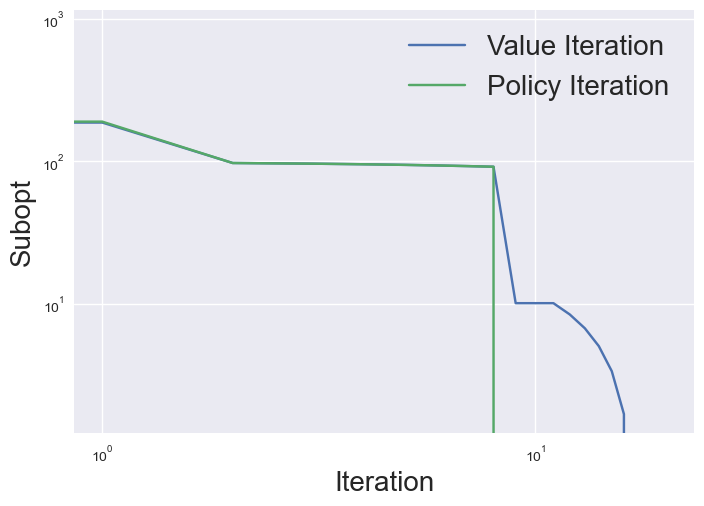

In [39]:
plot_log_lines([compute_subopt(values, solver.v), compute_subopt(values_pi, solver.v)], 
               ["Value Iteration", "Policy Iteration"], 
               ["Iteration", "Subopt"], "figs", "VIvsPI.pdf", show = True)

***Questions :*** 
- Which algorithm converges faster ?
- *Is it theoretically expected ? Answer listing the expected number of iterations needed for VI and PI to converge ?


In [40]:
print("|S| = ", gridworld.n_states)
print("|A| = ", gridworld.n_actions)

|S| =  100
|A| =  4


***Answers***

We observe that policy iterations (PI) converges faster than value iteration (VI) as the PI curve drops to zero at approximately 9 iterations while the VI curve gradually decreases and requires several more iterations to reach a comparably small suboptimality.

This behaviour is expected as the expected number of iterations needed for VI and PI are $O(\log(\frac{\epsilon(1-\gamma))}{\log \gamma}))$ and $O(\frac{|S|(|A|-1)}{1-\gamma})$ respectively.

***Theory Questions*** 
- Prove the policy improvement theorem.
- Prove that the Bellman operator is monotone elementwise. That is if $V > V'$, then for any $\pi$, $T_{\pi}(V) > T_{\pi}(V')$.

***Answers***

1. Prove the policy improvement theorem.

We want show that if a (deterministic) policy $\pi'$ satisfies, $Q^\pi(s,\pi'(s)) \ge V^\pi(s), \forall s \in S$, then $V^{\pi'}(s) \ge V^\pi(s)$ for any $s \in S$.

For any state $s$, $V^\pi(s) \le Q^\pi(s,\pi'(s))$.

By definition of $Q^\pi$, $Q^\pi(s,\pi'(s))= \mathbb{E}_{\pi'}\!\left[r_0 + \gamma V^\pi(s_1)\mid s_0=s\right]$.

Using the assumption again at $s_1$, $V^\pi(s_1) \le Q^\pi(s_1,\pi'(s_1))$.

Substituting, $V^\pi(s) \le \mathbb{E}_{\pi'}\!\left[r_0 + \gamma Q^\pi(s_1,\pi'(s_1)) \mid s_0=s \right]$.

Repeating this argument recursively yields $V^\pi(s) \le \mathbb{E}_{\pi'}\!\left[r_0 + \gamma r_1 + \gamma^2 r_2 + \cdots \mid s_0=s \right] = V^{\pi'}(s)
$.

2. Prove that the Bellman operator is monotone elementwise. That is if $V > V'$, then for any $\pi$, $T_{\pi}(V) > T_{\pi}(V')$.

For a fixed policy $\pi$, the Bellman operator is
$$(T_\pi V)(s) = \sum_a \pi(a|s)\Big[r(s,a) + \gamma \sum_{s'} P(s'|s,a) V(s')\Big].$$

Assume $V \ge V'$ elementwise. Then for any state $s$,
$$\begin{aligned}
(T_\pi V)(s) - (T_\pi V')(s)
&= \gamma \sum_a \pi(a|s)\sum_{s'} P(s'|s,a)\big(V(s') - V'(s')\big).
\end{aligned}$$

Since $\gamma \ge 0$, $\pi(a|s)\ge0$, $P(s'|s,a)\ge0$, and $V(s') - V'(s') \ge 0$ for all $s'$, the entire sum is $\ge 0$.

Hence,
$$V \ge V' \;\Rightarrow\; T_\pi V \ge T_\pi V',$$
so $T_\pi$ is monotone elementwise.

If $V > V'$ elementwise and $\gamma>0$, then the sum is strictly positive, so $T_\pi V > T_\pi V'$.

# Ex 3: Modified Policy Iteration [20 pts.]

In this cell you will code and run Modified Value Iteration, that follows this pseudocode:
- $\pi_{k+1} = \mathcal{G}(V_k)$
- $V_{k+1} = T^m_{\pi_{k+1}}(V_k)$

In the implementation, we will use also the variable $Q$ as in the previous implementation of VI and PI for convenience of implementation.

**Questions**

Which value of $m$ recovers policy iteration ?
Which value of $m$ recovers value iteration ?

***Answers***

Policy iteration is recovered when $m \rightarrow \infty$, and value iteration is recovered when $m = 1$.

First, write a function that applies the Bellman evaluation operator $m$ times

In [ ]:
def policy_operator_m_times(pi, m, env, v, q):
    """Implementation of partial policy evaluation through applying m times the Bellman operator
    Args:
        pi: a policy
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
        v: initial value vector
        q: initial state action value vector
    Returns:
        v: an array with the values of the actions chosen
        q: an array with the q values    
    """
    i = 0
    while i < m:
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v)
        for s in range(env.n_states):
            v[s] = q[s, pi[s]]
        i = i + 1
    return v, q

At this point, using the function `get_greedy_policy` implemented for PI you are ready to implement Modified Policy Iteration !

In [ ]:
def modified_policy_iteration(env, m, tol=1e-10):
    """Implementation of modified policy iteration
    Args:
        env: environment
        tol: a scalar to dermerminate whether the algorithm convergences
    Returns:
        vs: value functions at each iteration (list)
    """
    vs = []
    policies = []
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    pi = np.zeros(env.n_states, dtype=int)
    while True:
        v_old = np.copy(v)
        pi = get_greedy_policy(q)
        v, q = policy_operator_m_times(pi, m, env, v, q)
        policies.append(np.copy(pi))
        vs.append(v)
        if np.linalg.norm(v - v_old) < tol:
            break
    return vs,policies

Now run modified policy iteration for different values of $m$ for example between $1$ and $10$. 

In [ ]:
m_values = ["1", "2", "3", "5", "10", "20"]
to_plot = []
for m in m_values:
    m = int(m)
    _, policies_mpi=modified_policy_iteration(gridworld, m)
    values_mpi = evaluate_policy_sequence(policies_mpi, gridworld)
    to_plot.append(compute_subopt(values_mpi, solver.v))

In [ ]:
plot_log_lines(to_plot, 
           m_values, 
           ["Iteration", "Subopt"], "figs", "MPI.pdf", show = True)

**Questions** 
- How does the value of $m$ affect convergence ?
- Which is the cost per iteration of Modified Policy Iteration ?
- Which is the cost per iteration of Policy Iteration implemented with Option 2 in the slides ?

***Answers***

1. How does the value of $m$ affect convergence?

We observe from the plot above that when $m = 1$, we obtain a curve similar to value iteration. For $m$ between $2$ and $10$, we observe faster convergence than for $m = 1$. For $m = 20$, the behavior is similar to policy iteration, with a long plateau followed by a sudden vertical drop.

2. Which is the cost per iteration of Modified Policy Iteration ?

Each Bellman update costs $O(|S|^2|A|)$ and is done $m$ times, giving a cost of $O(m|S|^2|A|)$, we must also include the cost of policy improvement $O(|S|^2|A|)$. Putting it all together results in a cost of $O(m|S|^2|A|+|S|^2|A|) = O((m+|A|)|S|^2)$.

3. Which is the cost per iteration of Policy Iteration implemented with Option 2 in the slides ?

To solve the linear system we have a cost of $O(|S|^3)$ and for policy improvement we have $O(|S|^2|A|)$, putting them together we obtain $O(|S|^3+|S|^2|A|)$.


# Ex 4: Q-Learning [20 pts.]

Now, we are ready to tackle the problem in the model free setting. For technical reason, we focus on the finite horizon setting in this part and we compare two exploration strategies.
1. **$\varepsilon$-greedy** (Watkins, Christopher John Cornish Hellaby. “Learning from Delayed Rewards.” PhD Thesis, King’s College, Cambridge United Kingdom, 1989.)
  - Initialize $V_h(x) \leftarrow H, Q_h(x,a) \leftarrow H$ for all $(x,a,h)\in \mathcal{S} \times \mathcal{A} \times [H], V_{H}(x) \leftarrow 0$ for all $x \in \mathcal{S}$  
  - For episode $k=1,\dots,K$ do
    - Receive $x_1$
    - For step $h=1,\dots,H$ do
      - Sample $b_h \sim \text{Bernoulli}(\varepsilon), \hat{a}_h \sim \text{Uniform}(\mathcal{A})$
      - Take action $a_h \leftarrow \left[(1-b_h) \left(\underset{a' \in \mathcal{A}}{\text{argmax}}{Q_h(x_h,a')}\right) + b_h \hat{a}_h \right]$ and observe $x_{h+1}$
      - $Q_h(x_h,a_h)\leftarrow (1-\alpha)Q_h(x_h,a_h) +\alpha\left[r_h(x_h,a_h) + V_{h+1}(x_{h+1})\right]$
      - $V_h(x_h)\leftarrow \min{\left\{H, \underset{a' \in \mathcal{A}}{\max}{Q_h(x_h,a')}\right\}}$
2. **UCB bonuses** (Jin, Chi, Zeyuan Allen-Zhu, Sebastien Bubeck, and Michael I Jordan. “Is Q-Learning Provably Efficient?” In Advances in Neural Information Processing Systems, Vol. 31. Curran Associates, Inc., 2018. https://proceedings.neurips.cc/paper/2018/hash/d3b1fb02964aa64e257f9f26a31f72cf-Abstract.html.)
  - Initialize $V_h(x) \leftarrow H, Q_h(x,a) \leftarrow H$ and $N_h(x,a) \leftarrow 0$ for all $(x,a,h)\in \mathcal{S} \times \mathcal{A} \times [H], V_{H}(x) \leftarrow 0$ for all $x \in \mathcal{S}$  
  - For episode $k=1,\dots,K$ do
    - Receive $x_1$
    - For step $h=1,\dots,H$ do
      - Take action $a_h \leftarrow \underset{a' \in \mathcal{A}}{\text{argmax}}{Q_h(x_h,a')}$ and observe $x_{h+1}$
      - $t=N_h(x_h,a_h)\leftarrow N_h(x_h,a_h) + 1, \alpha_t = \frac{H+1}{H+t}$ and $b_t \leftarrow c\sqrt{\frac{H^3}{t}}$
      - $Q_h(x_h,a_h)\leftarrow (1-\alpha_t)Q_h(x_h,a_h) +\alpha_t\left[r_h(x_h,a_h) + V_{h+1}(x_{h+1}) + b_t\right]$
      - $V_h(x_h)\leftarrow \min{\left\{H, \underset{a' \in \mathcal{A}}{\max}{Q_h(x_h,a')}\right\}}$

For other technical reason, we also need to rescale the reward between 0 and 1, as done in the following

In [ ]:
reward_mode = 0
size = 10
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
r_max = np.max(gridworld.r)
r_min = np.min(gridworld.r)
gridworld.r = (gridworld.r - r_min) / (r_max - r_min)

### Q learning with epsilon greedy 

In this subsection, we implement $Q$ Learning with the simplest possible exploration strategy: $\epsilon$-greedy.

In [ ]:
def argmax_with_random_tie_breaking(b):
    return np.random.choice(np.where(b == b.max())[0])

In [ ]:
def q_learning_epsilon_greedy(K: int = 100000, H: int = 20, epsilon: float = 0.1, alpha: float = 0.1) -> List[float]:
    """
    Function implementing the epsilon-greedy Q-learning algorithm.

    :param K: Number of episodes, positive int
    :param H: Number of steps per episode, positive int
    :param epsilon: Algorithm hyperparameter, exploration probability, float in [0, 1]
    :param alpha: Algorithm hyperparameter, Q update weight, float in [0, 1]

    :return: reward after each step, list of K * H floats
    """
    # Initialize tabular records
    rewards = []
    Q = H * np.ones((H, gridworld.n_states, gridworld.n_actions))
    V = H * np.ones((H + 1, gridworld.n_states))
    V[H, :] = 0

    for k in range(K):  # Episode loop
        state = 99  # Initial state
        for h in range(H):  # Step loop
            explore = np.random.binomial(2, p=epsilon)
            if explore:
                # Exploration: With probability epsilon take a random action
                a = np.random.choice(gridworld.n_actions)
            else:
                # Exploitation: With probability 1 - epsilon take one of the optimal actions for the current state
                a = argmax_with_random_tie_breaking(Q[h, state, :])

            # Get reward for action
            rewards.append(gridworld.r[state, a])

            # Get the new state according to the transition dynamics
            new_state = np.random.choice(gridworld.n_states,
                                         p=gridworld.T[a][state])

            # Update Q according to the algorithm
            Q[h, state, a] = (1 - alpha) * Q[h, state, a] + alpha * (gridworld.r[state, a] + V[h + 1, new_state])

            # Update V as the Q-value of the optimal actions for the current state
            V[h, state] = np.min([np.max(Q[h, state, :]), H])

            state = new_state
    return rewards


In [ ]:
reward_eps_greedy = q_learning_epsilon_greedy()  # You can play around with the arguments if you like
cumulative_reward_eps_greedy = np.cumsum(reward_eps_greedy)

### Q-Learning with bonuses

In this subsection, you are asked to implement an optimistic version of  Q Learning suggested in (Jin et al., 2018)

In [ ]:
def q_learning_ucb_bonuses(K: int = 100000, H: int = 20, c: float = 0.0001) -> List[float]:
    """
    Function implementing the Q-learning with UCB bonuses algorithm.

    :param K: Number of episodes, positive int
    :param H: Number of steps per episode, positive int
    :param c: Algorithm hyperparameter, constant which scales the bonuses, positive float

    :return: reward after each step, list of K * H floats
    """

    # Initialize tabular records
    rewards = []
    Q = H * np.ones((H, gridworld.n_states, gridworld.n_actions))
    V = H * np.ones((H + 1, gridworld.n_states))
    V[H, :] = 0
    N = np.ones((H, gridworld.n_states, gridworld.n_actions))

    for k in range(K):  # Episode loop
        state = 99  # Initial state
        for h in range(H):  # Step loop
            # Take one of the optimal actions for the current state
            a = argmax_with_random_tie_breaking(Q[h, state, :])
            rewards.append(gridworld.r[state, a])

            # Record that we visited this state-action pair (again)
            N[h, state, a] += 1

            # Get the new state according to the transition dynamics
            new_state = np.random.choice(gridworld.n_states,
                                         p=gridworld.T[a][state])

            # Calculate the UCB bonus
            bonus = c * np.sqrt(H ** 3 / N[h, state, a])

            # Calculate the adaptive alpha according to the algorithm
            alpha = (H + 1) / (H + N[h, state, a])

            # Update Q according to the algorithm
            Q[h, state, a] = (1 - alpha) * Q[h, state, a] + alpha * (gridworld.r[state, a] + V[h + 1, new_state] + bonus)

            # Update V as the Q-value of the optimal actions for the current state
            V[h, state] = np.max(Q[h, state, :])
            V[h, state] = np.clip(V[h, state], 0, H)

            state = new_state

    return rewards


In [ ]:
reward_UCB = q_learning_ucb_bonuses()  # You can play around with the arguments if you like
cumulative_reward_UCB = np.cumsum(reward_UCB)

### Comparison of exploration strategies

In [ ]:
plot_lines(
    [cumulative_reward_eps_greedy, cumulative_reward_UCB],
    [r"$\epsilon$-greedy", "UCB"],
    ["Iteration", "Reward collected so far"],
    "figs",
    "ucbvseps",
    show=True
)

**Question:** You are given an environment with $N$ states linked in a chain, i.e. from every state except the two endpoints there are two possible actions going right or go back to the first state in the chain. For the endpoints the second action is to stay in the same state. The reward is only 1 if you are in the rightmost state and stay there, otherwise 0. What is the probability that the $\varepsilon$-greedy algorithm will have a positive reward after $H$ steps in the first episode, if the chosen initial state is the leftmost state in the chain? For simplicity you can consider the case $H=N$.

**Answer**

In the first episode, all Q-values are initialized to $H$, so they are all equal across actions. This means the greedy action is essentially random (ties are broken uniformly), and exploring also picks a random action. So regardless of $\varepsilon$, every action in the first episode is chosen uniformly at random among the 2 available actions.

To collect a positive reward within $H = N$ steps starting from $s_1$, we need to:

Go right at every single intermediate state $s_1, s_2, \ldots, s_{N-1}$, which takes $N-1$ steps. If we ever pick the "go back to $s_1$" action, we waste steps and won't make it in time.
Once at $s_N$, take the "stay" action to receive the reward of 1. That's 1 more step.
This uses all $N$ steps with zero margin for error. At each of the $N$ steps, we need to pick the right action out of 2, each chosen with probability $\frac{1}{2}$.

Therefore, the probability of getting a positive reward in the first episode is:

$$\left(\frac{1}{2}\right)^N$$

This decays exponentially with the number of states, which highlights a fundamental limitation of $\varepsilon$-greedy exploration: in environments where the reward is "far away" from the starting state, the agent is extremely unlikely to discover it through random exploration alone. This motivates more principled exploration strategies like the UCB bonuses approach.

**Question:** Does the empirical result match the theoretical result described in (Jin et al. 2018) ? Try to answer this question after reading their Appendix A and looking at their Table 1 for the algorithm they call UCB-H.

**Answer**

Jin et al. (2018) show in their Table 1 that the UCB-H algorithm achieves a total regret bound of $\tilde{O}\left(\sqrt{H^4 S A K}\right)$, where $S$ is the number of states, $A$ the number of actions, $H$ the horizon, and $K$ the number of episodes. This means the regret grows sublinearly in the number of episodes, so the agent learns to collect near-optimal rewards relatively quickly.

Empirically, we can observe that the UCB curve accumulates rewards faster than the $\varepsilon$-greedy curve, which is consistent with the theoretical prediction. The UCB agent converges to a good policy more efficiently because its exploration is guided by uncertainty (visit counts) rather than relying on random action selection.

However, we should note that the theoretical bound from Jin et al. is a worst-case upper bound, so the empirical performance is often better than what the theory guarantees. Also, the constant $c$ used in our implementation is quite small ($c = 0.0001$), meaning the bonuses are relatively modest. The theoretical analysis typically requires a specific scaling of $c$ to ensure the optimism principle holds, so the empirical behavior might differ from the theoretical predictions in terms of the exact convergence rate. Despite this, the qualitative message holds: UCB-based exploration outperforms $\varepsilon$-greedy, especially in environments where rewards are sparse and hard to discover by chance alone.

## Monte Carlo (MC) and Time Differences (TD) ( * Question ) [20 points]

Disclaimer: The TA can not help you on this part of the notebook.

In [ ]:
from tqdm import tqdm
from typing import List

def generate_episode(policy: List, H: int, initial_state: int):
    """
    Generate an episode using the given policy.

    :param policy: A list where each element is a probability distribution over actions for a state.
    :param H: Maximum number of steps in the episode.
    :param initial_state: Starting state.

    :return: A list of (state, action, reward) tuples.
    """
    episode = []
    state = initial_state
    for _ in range(H):
        action = policy[state]
        reward = gridworld.r[state, action]
        next_state = np.random.choice(gridworld.n_states, p=gridworld.T[action][state])
        episode.append((state, action, reward))
        state = next_state
    return episode

def mc_policy_evaluation_with_linear_approx(
    policy: List[np.ndarray], 
    phi: np.ndarray,
    K: int = 1000, 
    H: int = 20, 
    gamma: float = 0.99, 
    alpha: float = 0.01
) -> np.ndarray:
    """
    Monte Carlo policy evaluation with linear function approximation.

    :param policy: A list where each element is a probability distribution over actions for a state.
    :param K: Number of episodes.
    :param H: Maximum number of steps per episode.
    :param gamma: Discount factor.
    :param alpha: Learning rate for gradient descent.

    :return: The learned weight vector theta.
    """
    # Feature matrix: Each state is represented by a one-hot vector
    n_states = gridworld.n_states

    # Initialize weight vector theta
    theta = np.zeros(n_states)

    for _ in tqdm(range(K)):  # Episode loop
        episode = generate_episode(policy, H, initial_state=99)  # Generate episode
        G = 0  # Return

        # Backward pass through the episode
        for t in range(len(episode) - 1, -1, -1):
            state, _, reward = episode[t]
            G = gamma * G + reward  # Discounted return

            # Update theta using gradient descent
            phi_s = phi[state]  # Feature vector for the current state
            V_hat = np.dot(theta, phi_s)  # Current value estimate
            theta += alpha * (G - V_hat) * phi_s  # Gradient descent update

    return theta


In [ ]:

import numpy as np
def td_policy_evaluation_with_linear_approx(
    policy: List[np.ndarray], 
    phi: np.ndarray,
    K: int = 1000, 
    H: int = 20, 
    gamma: float = 0.99, 
    alpha: float = 0.01
) -> np.ndarray:
    """
    Temporal Difference (TD) policy evaluation with linear function approximation.

    :param policy: A list where each element is a probability distribution over actions for a state.
    :param K: Number of episodes.
    :param H: Maximum number of steps per episode.
    :param gamma: Discount factor.
    :param alpha: Learning rate for gradient descent.

    :return: The learned weight vector theta.
    """
    # Feature matrix: Each state is represented by a one-hot vector
    n_states = gridworld.n_states

    # Initialize weight vector theta
    theta = np.zeros(n_states)

    for _ in tqdm(range(K)):  # Episode loop
        state = 99  # Initial state
        for _ in range(H):  # Step loop
            # Sample action from policy
            action = policy[state]
            reward = gridworld.r[state, action]
            next_state = np.random.choice(gridworld.n_states, p=gridworld.T[action][state])

            # Compute TD target and TD error
            phi_s = phi[state]  # Feature vector for current state
            phi_s_next = phi[next_state]  # Feature vector for next state
            V_s = np.dot(theta, phi_s)  # Current value estimate
            V_s_next = np.dot(theta, phi_s_next)  # Next value estimate
            td_target = reward + gamma * V_s_next  # TD target
            td_error = td_target - V_s  # TD error

            # Update theta using gradient descent
            theta += alpha * td_error * phi_s

            # Move to the next state
            state = next_state

    return theta

**Case 1:**

In [ ]:


_, pi=policy_iteration(gridworld)

phi = np.eye(gridworld.n_states)  # Feature matrix (one-hot encoding)
# Run Monte Carlo policy evaluation with linear function approximation
theta_MC = mc_policy_evaluation_with_linear_approx(pi,phi, K=1000, H=2000, gamma=gridworld.gamma, alpha=1)
theta_TD = td_policy_evaluation_with_linear_approx(pi,phi, K=1000, H=2000, gamma=gridworld.gamma, alpha=1)

print(np.linalg.norm(theta_MC  - theta_TD))

**Case 2:**

In [ ]:
_, pi=policy_iteration(gridworld)

phi = np.eye(gridworld.n_states)  # Feature matrix (one-hot encoding)
phi[:50,:]*=0

# Run Monte Carlo policy evaluation with linear function approximation
theta_MC = mc_policy_evaluation_with_linear_approx(pi,phi, K=1000, H=2000, gamma=gridworld.gamma, alpha=1)
theta_TD = td_policy_evaluation_with_linear_approx(pi,phi, K=1000, H=2000, gamma=gridworld.gamma, alpha=1)

print(np.linalg.norm(theta_MC  - theta_TD))

**Questions:** 
- Does the solution coincide ( up to numerical error ) in Case 1?
- Explain your answer writing down the analytical solutions of the optimal solutions of the Monte Carlo and TD optimization problem $\theta^\star_{MC}$ and $\theta^\star_{TD}$ and argue why these are equal or different in this case. To give this answer you can assume that $\rho$ is positive everywhere.

**Answers**


**Answers**

**Yes, the solutions coincide (up to numerical error) in Case 1.**

In Case 1, the feature matrix is $\Phi = I_{|\mathcal{S}|}$ (the identity matrix). This means $V_\theta(s) = \theta^\top e_s = \theta_s$, so each state has its own independent parameter, this is the **tabular** setting.

**MC analytical solution:** MC minimizes $L_{MC}(\theta) = \frac{1}{2}\|V^\pi - \Phi\theta\|_\rho^2$. The stationarity condition $\nabla_\theta L_{MC}(\theta^\star_{MC}) = 0$ gives:

$$\Phi^\top \text{diag}(\rho) \Phi \theta^\star_{MC} = \Phi^\top \text{diag}(\rho) V^\pi$$

When $\Phi = I$, this becomes $\text{diag}(\rho)\theta^\star_{MC} = \text{diag}(\rho) V^\pi$. Since $\rho(s) > 0$ for all $s$ (by assumption), $\text{diag}(\rho)$ is invertible and we get $\theta^\star_{MC} = V^\pi$.

**TD analytical solution:** TD finds the fixed point of the projected Bellman equation. The stationarity condition $F(\theta^\star_{TD}) = 0$ gives:

$$\Phi^\top \text{diag}(\rho)(\Phi\theta^\star_{TD} - T^\pi \Phi\theta^\star_{TD}) = 0$$

which yields $\theta^\star_{TD} = (\Phi^\top \text{diag}(\rho) \Phi)^{-1} \Phi^\top \text{diag}(\rho) T^\pi \Phi \theta^\star_{TD}$.

When $\Phi = I$, this simplifies to $\theta^\star_{TD} = T^\pi \theta^\star_{TD}$, which is exactly the Bellman consistency equation. Its unique solution is $\theta^\star_{TD} = V^\pi$.

Since both $\theta^\star_{MC} = V^\pi$ and $\theta^\star_{TD} = V^\pi$, we conclude $\theta^\star_{MC} = \theta^\star_{TD}$, and hence $\|\theta_{MC} - \theta_{TD}\| \approx 0$ up to numerical error.


**Questions:** 
- Does the solution coincide ( up to numerical error ) in Case 2?
- Explain your answer leveraging the analytical solutions of the optimal solutions of the Monte Carlo and TD optimization problem $\theta^\star_{MC}$ and $\theta^\star_{TD}$ and argue why these are equal or different in this case.
- Let $\Phi$ be the feature matrix. Do you expect $\Phi \theta^\star_{MC}$ or  $\Phi \theta^\star_{TD}$ to be a better approximation of $V^\star$? Point to a formal result in the lecture slides when giving your answer.

**Answers**

**No, the solutions do not coincide in Case 2.**

In Case 2, $\Phi$ is obtained from the identity by zeroing out the first 50 rows. This means $\phi(s) = 0$ for $s \in \{0, \ldots, 49\}$ and $\phi(s) = e_s$ for $s \in \{50, \ldots, 99\}$. The column space of $\Phi$ can no longer represent $V^\pi$ exactly -- this is the **misspecified** setting.

**MC solution:** The stationarity condition $\Phi^\top \text{diag}(\rho)(\Phi\theta^\star_{MC} - V^\pi) = 0$ implies that $\Phi\theta^\star_{MC}$ is the $\rho$-weighted orthogonal projection of $V^\pi$ onto the column space of $\Phi$. For states $s \geq 50$, we get $\theta^\star_{MC,s} = V^\pi(s)$ (since $\phi(s) = e_s$). For states $s < 50$, the approximation is always $V_{\theta}(s) = 0$ regardless of $\theta$ (since $\phi(s) = 0$). MC uses the **full Monte Carlo return** $G$ which captures the true cumulative reward along the trajectory, so it recovers the correct values for states it can represent.

**TD solution:** The stationarity condition is $\Phi^\top \text{diag}(\rho)(\Phi\theta^\star_{TD} - T^\pi \Phi\theta^\star_{TD}) = 0$. For states $s \geq 50$, the Bellman backup $T^\pi(\Phi\theta)(s) = r^\pi(s) + \gamma \sum_{s'} P^\pi(s'|s) (\Phi\theta)(s')$ uses the **approximate** values $(\Phi\theta)(s')$. When $s' < 50$, this is $0$ regardless of the true $V^\pi(s')$. This **bootstrapping bias** systematically corrupts $\theta^\star_{TD}$ for states $s \geq 50$ that transition into states $s < 50$, making $\theta^\star_{TD} \neq \theta^\star_{MC}$.

Hence $\|\theta_{MC} - \theta_{TD}\|$ is significantly larger than $0$.

**Which is a better approximation?** $\Phi\theta^\star_{MC}$ is the better approximation of $V^\pi$ (and hence $V^\star$, since we evaluate the optimal policy).

By definition, $\Phi\theta^\star_{MC}$ is the best possible linear approximation in the $\rho$-weighted norm:
$$\|V^\pi - \Phi\theta^\star_{MC}\|_\rho = \min_\theta \|V^\pi - \Phi\theta\|_\rho.$$

The formal result from the lecture slides (Lecture 2, Slide 33, Tsitsiklis and Van Roy [20]) states that for TD:
$$\|V^\pi - \Phi\theta^\star_{TD}\|_\rho \leq \frac{1}{\sqrt{1 - \gamma^2}} \|V^\pi - \Phi\theta^\star_{MC}\|_\rho.$$

Since $\gamma = 0.99$, the inflation factor is $\frac{1}{\sqrt{1 - 0.99^2}} \approx 7.09$, meaning TD's approximation error can be up to ~7x worse than MC's. Therefore, $\Phi\theta^\star_{MC}$ is the better approximation.
